In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans

df=pd.read_csv('/content/Dry_Bean.csv')
print("Dataset shape:",df.shape)
print("\nFirst 5 rows")
display(df.head())

Dataset shape: (13611, 17)

First 5 rows


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


/tmp/ipykernel_4617/3817432672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Class',data=df, palette='viridis')


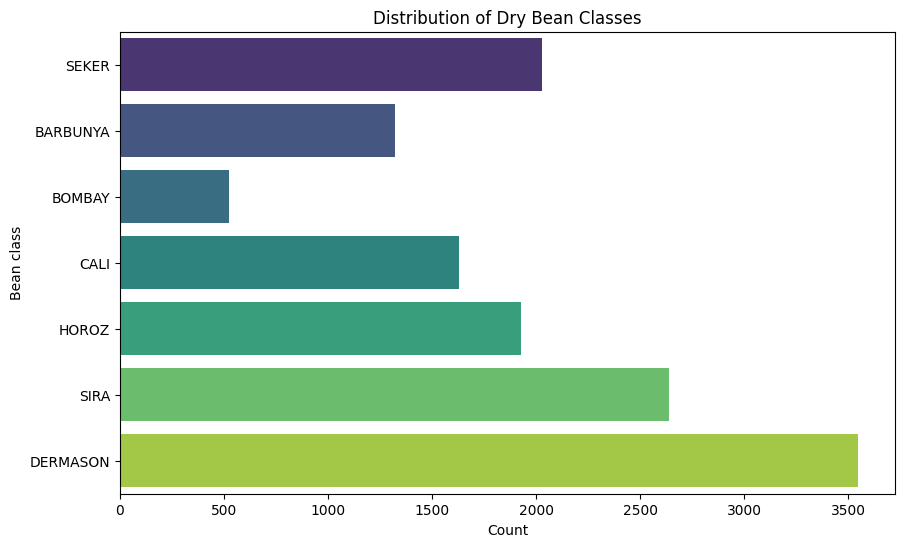

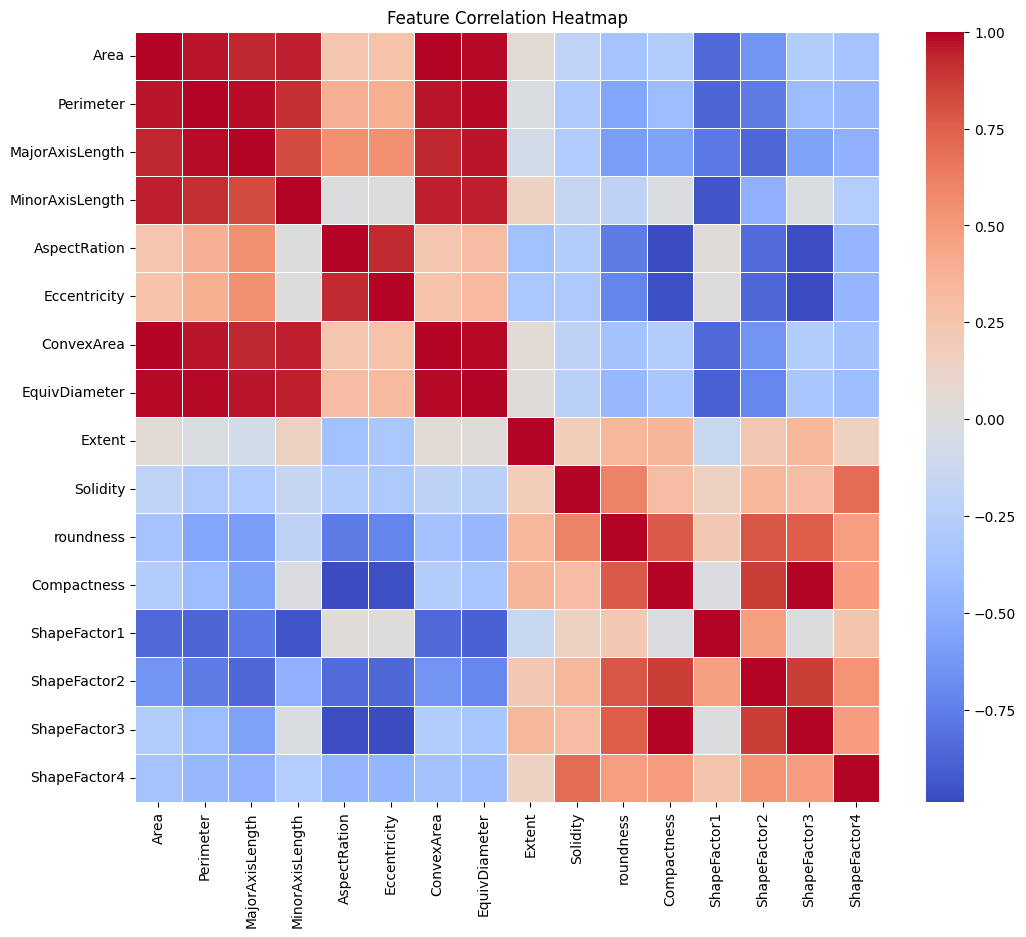

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='Class',data=df, palette='viridis')
plt.title('Distribution of Dry Bean Classes')
plt.xlabel('Count')
plt.ylabel("Bean class")
plt.show()

plt.figure(figsize=(12,10))
corr_matrix=df.drop('Class',axis=1).corr()
sns.heatmap(corr_matrix,annot=False,cmap="coolwarm",linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
X=df.drop('Class',axis=1)
y=df['Class']
label_encoder=LabelEncoder()
y_encoeded=label_encoder.fit_transform(y)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled, y_encoeded,test_size=0.2,random_state=42)
print("Training Data Shape", X_train.shape)
print("Testing Data Shape:" ,X_test.shape)

Training Data Shape (10888, 16)
Testing Data Shape: (2723, 16)


Logistic Regression
Accuracy: 0.926919


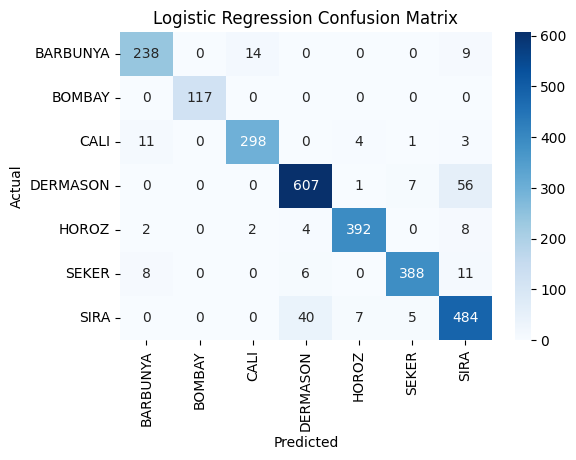

Random Forest
Accuracy: 0.925450


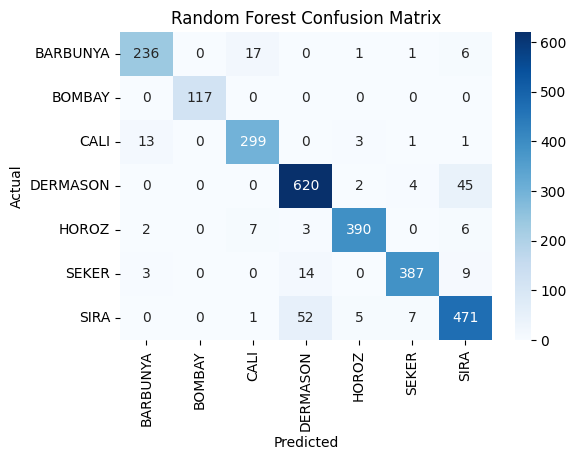

Suport Vector Machine
Accuracy: 0.933896


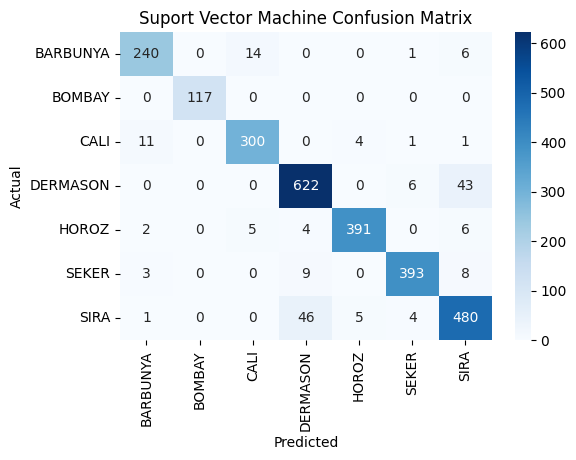

K-Nearest Neighbors
Accuracy: 0.923246


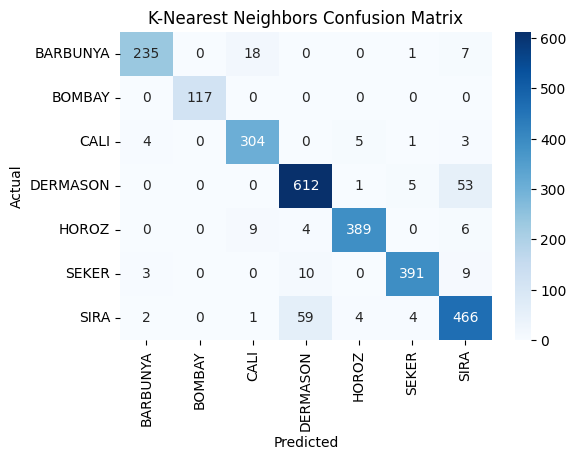

Neural Network (MLP)
Accuracy: 0.927653


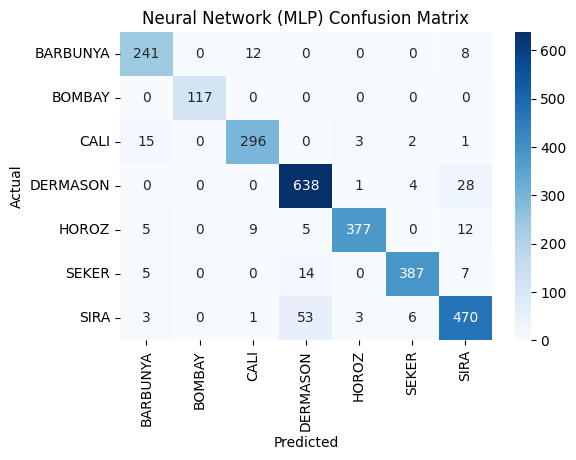

In [ ]:
models= {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "Suport Vector Machine": SVC(kernel='rbf'),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,50),max_iter=500,random_state=42)

}

results={}
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    results[name]=acc
    print(f"{name}")
    print(f"Accuracy: {acc:4f}")
    cm=confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel("Predicted")
    plt.show()


In [ ]:
print("\n 10 Fold Cross Validation")
kf=KFold(n_splits=10,shuffle=True,random_state=42)
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

cv_scores=cross_val_score(rf_model,X_scaled,y_encoeded,cv=kf,scoring='accuracy')
print(f"cross validation Accuracy score{cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


 10 Fold Cross Validation
cross validation Accuracy score[0.92951542 0.9235856  0.9235856  0.93460691 0.91991183 0.91476855
 0.93093314 0.92432035 0.91844232 0.92211609]
Mean CV accuracy: 0.9242
Standard Deviation: 0.0057



-- Unsupervised Learning K means cluster--


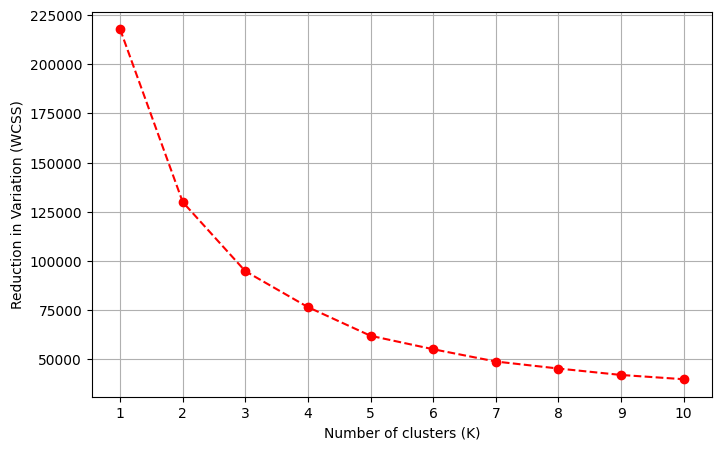

K-Means clustering completed


In [ ]:
print("\n-- Unsupervised Learning K means cluster--")
wcss=[]
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,init='k-means++',max_iter=300, n_init=10,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_range,wcss,marker='o',linestyle='--',color='red')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Reduction in Variation (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

kmeans_final=KMeans(n_clusters=7,init='k-means++',random_state=42,n_init=10)
clusters=kmeans_final.fit_predict(X_scaled)
print('K-Means clustering completed')

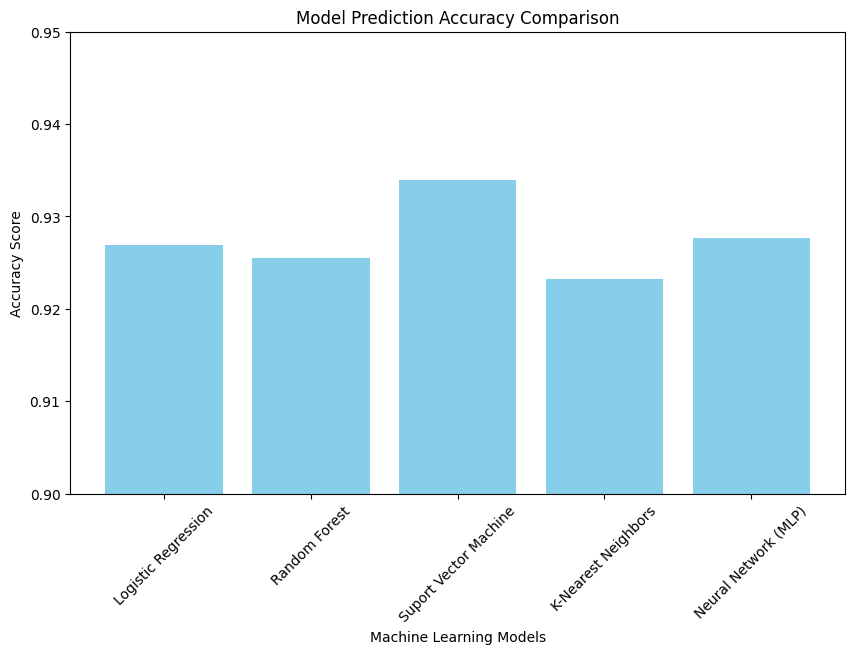

In [ ]:
models = list(results.keys())
accuracies = list(results.values())
plt.figure(figsize=(10,6))
plt.bar(models, accuracies, color='skyblue')
plt.title("Model Prediction Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0.90, 0.95)
plt.show()